In [1]:
# etl_eda_polars_psycopg3.py
from __future__ import annotations

import io
import os
import re
from pathlib import Path
from typing import Dict

import polars as pl
import psycopg
from psycopg import sql


In [2]:
BASE_COLS = (
        ["label"]
        + [f"int_feature_{i}" for i in range(1, 14)]
        + [f"cat_feature_{i}" for i in range(1, 27)]
    )  # 40 columns

TARGET_COLS = BASE_COLS + ["partition_file", "loaded_at"]

BATCH_ROWS = int(os.getenv("BATCH_ROWS", "200000"))

In [3]:
def list_csv_files(dataset_dir: Path) -> list[Path]:
    return sorted(dataset_dir.glob("*.csv"))

In [4]:
TARGET_TABLE = os.getenv("TARGET_TABLE", "mlops.ml_features")
CONTROL_TABLE = os.getenv("CONTROL_TABLE", "mlops.ingest_file_status")

In [5]:
from datetime import datetime, timezone

def normalize_batch(df: pl.DataFrame, file_name: str) -> pl.DataFrame:
    df = df.with_columns(
        [pl.col("label").cast(pl.Int16, strict=False)]
        + [pl.col(f"int_feature_{i}").cast(pl.Int64, strict=False) for i in range(1, 14)]
        + [pl.col(f"cat_feature_{i}").cast(pl.Utf8, strict=False) for i in range(1, 27)]
    )

    df = df.with_columns(
        pl.lit(file_name).alias("partition_file"),
       pl.lit(datetime.now(timezone.utc)).alias("loaded_at"),
    )

    return df.select(TARGET_COLS)

In [ ]:
def iterating_batches() -> None:
    # ---------- Config ----------
    DATASET_DIR = Path("/app/dataset/")

    files = list_csv_files(DATASET_DIR)
    if not files:
        raise FileNotFoundError(f"No .csv files in {DATASET_DIR.resolve()}")
           
    sorted_files = sorted(files, key=lambda path: int(path.stem.split('_')[1]))
    path = sorted_files[0]
    
    batched_reader =pl.read_csv_batched(
        source=path,
        has_header=False,
        separator="\t",
        new_columns=BASE_COLS,
        infer_schema_length=20000,
        truncate_ragged_lines=True,
        ignore_errors=True,
        batch_size=BATCH_ROWS,
    )

    batches = batched_reader.next_batches(1)
    df = batches[0]
    df =None if df.height == 0 else normalize_batch(df, path.name)
    
    # output = df.group_by("label").agg(pl.len().alias("count"))
    return df 
   



In [ ]:
output  =  iterating_batches()


In [ ]:
output.head()

label,int_feature_1,int_feature_2,int_feature_3,int_feature_4,int_feature_5,int_feature_6,int_feature_7,int_feature_8,int_feature_9,int_feature_10,int_feature_11,int_feature_12,int_feature_13,cat_feature_1,cat_feature_2,cat_feature_3,cat_feature_4,cat_feature_5,cat_feature_6,cat_feature_7,cat_feature_8,cat_feature_9,cat_feature_10,cat_feature_11,cat_feature_12,cat_feature_13,cat_feature_14,cat_feature_15,cat_feature_16,cat_feature_17,cat_feature_18,cat_feature_19,cat_feature_20,cat_feature_21,cat_feature_22,cat_feature_23,cat_feature_24,cat_feature_25,cat_feature_26,partition_file,loaded_at
i16,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,"datetime[μs, UTC]"
0,126,6316,40,null,null,0,0,3,46,0,null,187,40,"""f27d5bf0""","""58cc2d25""","""d507066e""","""f2463ffb""","""25e74633""","""6fcd6dcb""","""329dd03a""","""6032e7d9""","""2e4e821f""","""0fd00cb7""","""7e2537c9""","""12716184""","""e07cc34d""","""be4ee537""","""4a9e2549""","""4cdc3efa""","""d20856aa""","""b8170bba""","""0a1d513f""","""eca67369""","""993cc276""","""ec74014a""","""55dc7bcf""","""1b839a44""","""ff654802""","""b757e957""","""day_2.csv""",2026-03-06 22:39:11.570069 UTC
0,18,286,null,null,null,0,0,18,0,0,null,473382,null,"""62770d79""","""ade1656a""","""c7cc8b0d""","""90dfe17b""","""513057af""","""919c68e4""","""ed96a350""","""4f877969""","""2e4e821f""","""2e027dc1""","""0c7c4231""","""85365dca""","""bf78d0d4""","""be4ee537""","""72c9c91c""","""4cdc3efa""","""d20856aa""","""628f1b8d""","""9512c20b""","""c38e2f28""","""14f65a5d""","""25b1b089""","""d7c1fc0b""","""7ce3b956""","""ff654802""","""ed10571d""","""day_2.csv""",2026-03-06 22:39:11.570069 UTC
0,179,2773,11,null,4,0,0,12,11,0,4,15890,11,"""eb360940""","""7b831047""","""f80f9a19""","""f2463ffb""","""c6fc10d3""","""6fcd6dcb""","""120cba33""","""b69a2b08""","""dbe3aa6f""","""760df549""","""57606b4c""","""8e697d5e""","""a77a4a56""","""be4ee537""","""9eb57ff0""","""4cdc3efa""","""d20856aa""","""628f1b8d""","""139221a3""","""20221668""","""90aa3af8""","""48f4bfff""","""1e58e9f9""","""6060c9bb""","""d0b1afa5""","""2ccea557""","""day_2.csv""",2026-03-06 22:39:11.570069 UTC
0,null,292,null,634,1,0,0,-1,1,0,1,28805,null,"""92409874""","""c02275a8""","""dd6c8142""","""f2463ffb""","""0a0044e1""","""919c68e4""","""6822c450""","""4f877969""","""2e4e821f""","""7543ae9d""","""30495534""","""caed738f""","""bf78d0d4""","""be4ee537""","""7982f9b4""","""4cdc3efa""","""d20856aa""","""69bb317e""","""64083ab9""","""18e93d1f""","""7bcfeef2""","""ac1dc370""","""d7c1fc0b""","""9c504208""","""ff654802""","""2ccea557""","""day_2.csv""",2026-03-06 22:39:11.570069 UTC
0,136,1,22,null,null,0,0,32,29,0,null,875,27,"""5ff0cb6e""","""56b46623""","""ab93c93a""","""80b7260b""","""c6fc10d3""","""6fcd6dcb""","""71aa0699""","""14441867""","""2e4e821f""","""e0c2723c""","""bf63020b""","""12716184""","""e07cc34d""","""be4ee537""","""6159bba8""","""4cdc3efa""","""d20856aa""","""b8170bba""","""9512c20b""","""ea043cbb""","""685bf3ee""","""b4462dc6""","""d3510abf""","""f8cfe82d""","""ff654802""","""ed10571d""","""day_2.csv""",2026-03-06 22:39:11.570069 UTC


In [15]:
! pip install  seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# # If you have LazyFrame, collect first
# if isinstance(df, pl.LazyFrame):
#     df = df.collect()

label_col = "label"
cat_cols = [c for c in output.columns if c.startswith("cat_feature_")]
int_cols = [c for c in output.columns if c.startswith("int_feature_")]

# optional sampling for large data (faster plotting)
MAX_PLOT_ROWS = 1_000_000
plot_df = output if output.height <= MAX_PLOT_ROWS else output.sample(n=MAX_PLOT_ROWS, seed=42)


def plot_category_lines(data: pl.DataFrame, cols: list[str], top_n: int = 15):
    for col in cols:
        agg = (
            data.group_by([col, label_col])
            .len()
            .rename({"len": "count"})
        )

        top_vals = (
            agg.group_by(col)
            .agg(pl.sum("count").alias("total"))
            .sort("total", descending=True)
            .head(top_n)
            .select(col)
        )

        p = (
            agg.join(top_vals, on=col, how="inner")
            .sort([col, label_col])
            .to_pandas()
        )

        plt.figure(figsize=(12, 4))
        sns.lineplot(data=p, x=col, y="count", hue=label_col, marker="o")
        plt.title(f"{col}: category distribution by label (top {top_n})")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


In [17]:
def plot_int_lines(data: pl.DataFrame, cols: list[str], bins: int = 40):
    p = data.select([label_col] + cols).drop_nulls().to_pandas()

    for col in cols:
        plt.figure(figsize=(12, 4))
        for y_val, g in p.groupby(label_col):
            counts, edges = np.histogram(g[col].astype(float), bins=bins)
            centers = (edges[:-1] + edges[1:]) / 2
            plt.plot(centers, counts, marker=".", label=f"label={y_val}")

        plt.title(f"{col}: binned distribution by label")
        plt.xlabel(col)
        plt.ylabel("count")
        plt.legend()
        plt.tight_layout()
        plt.show()


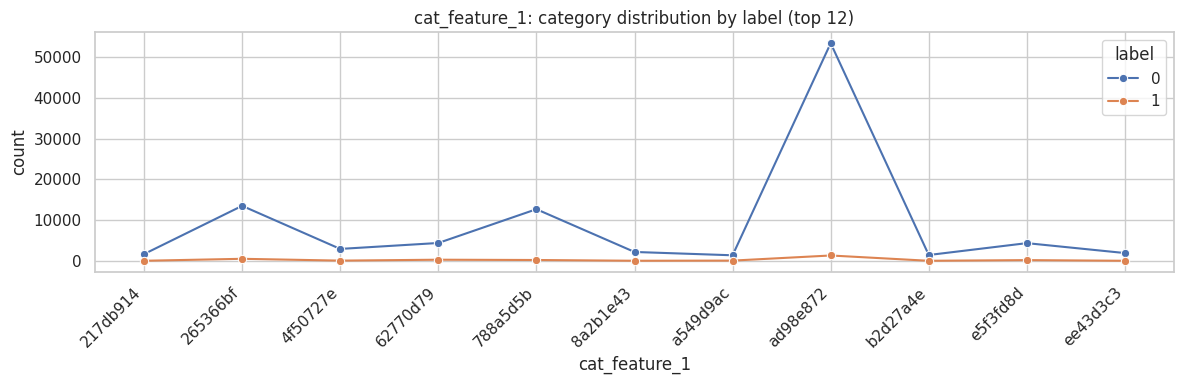

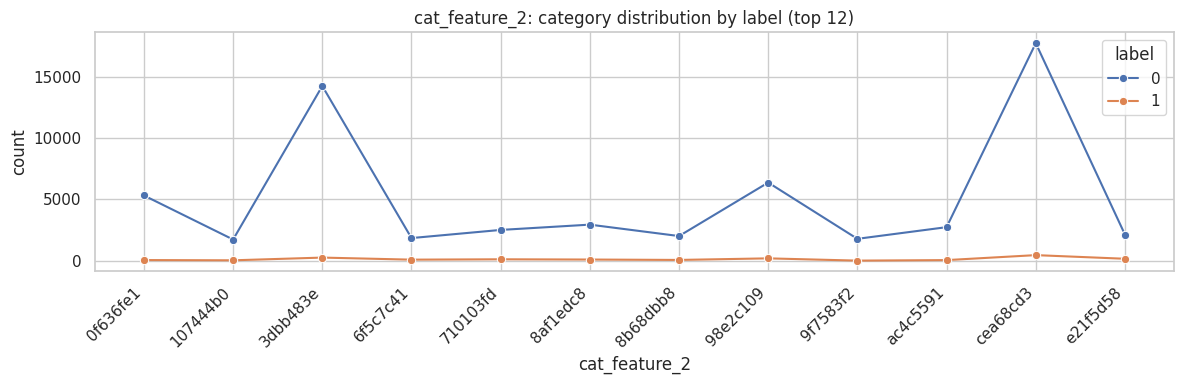

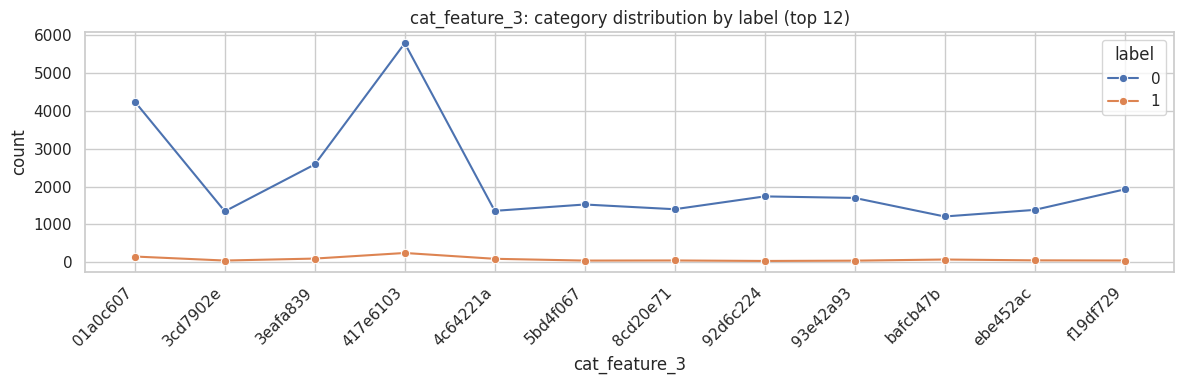

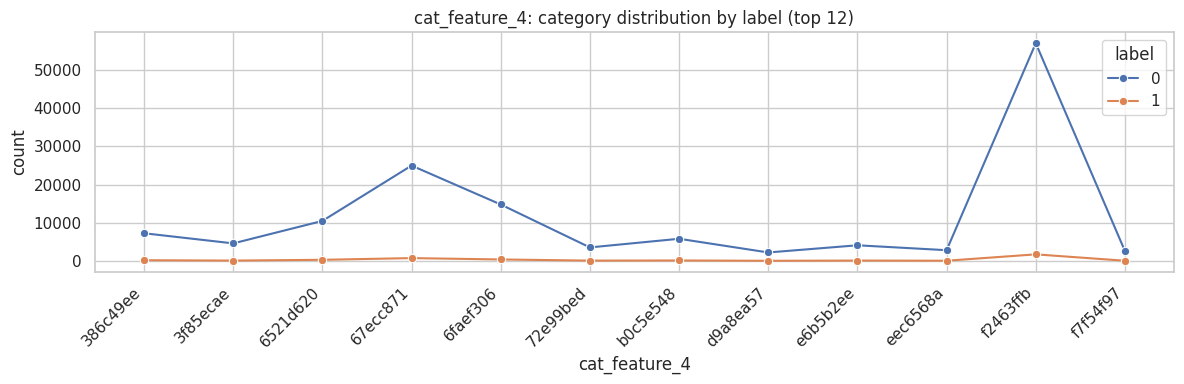

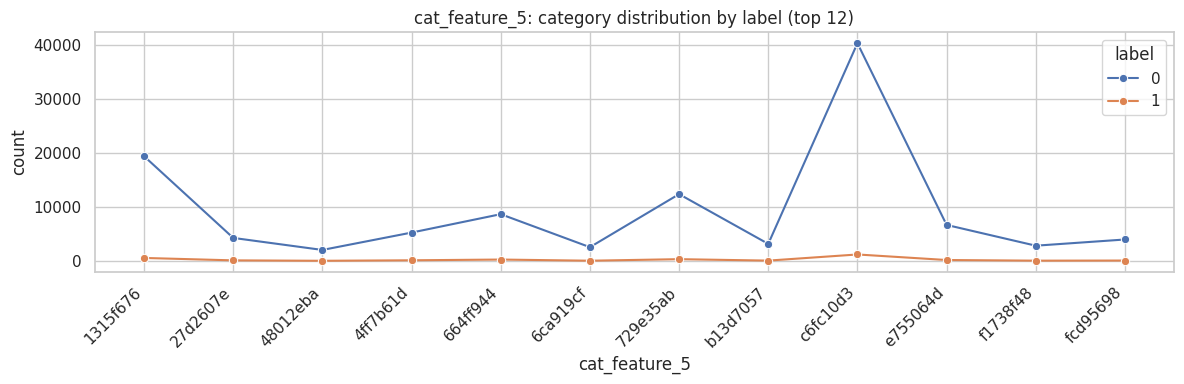

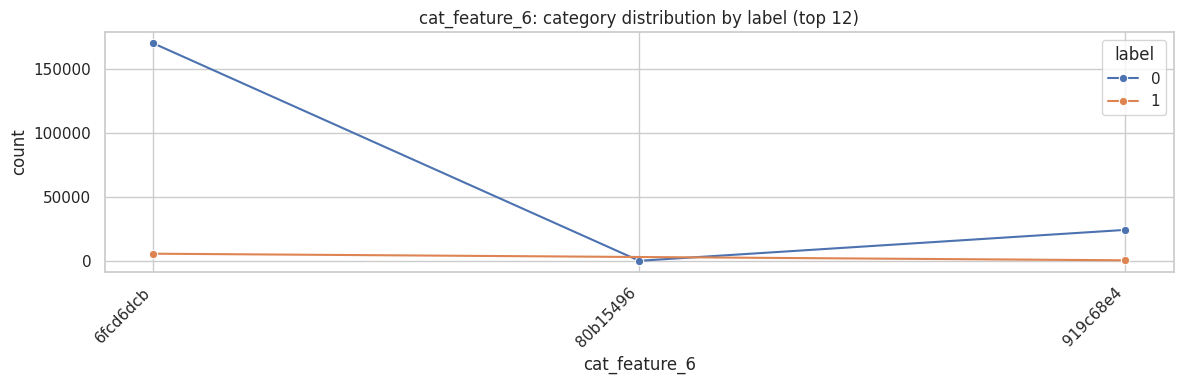

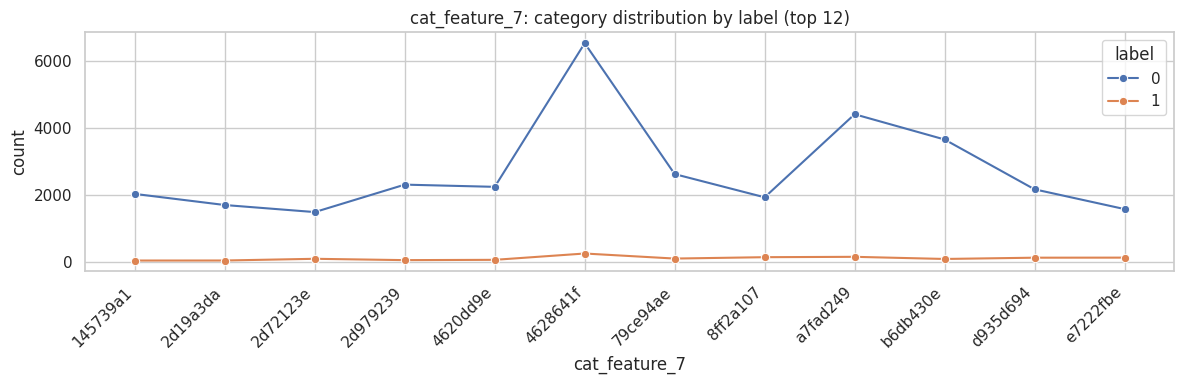

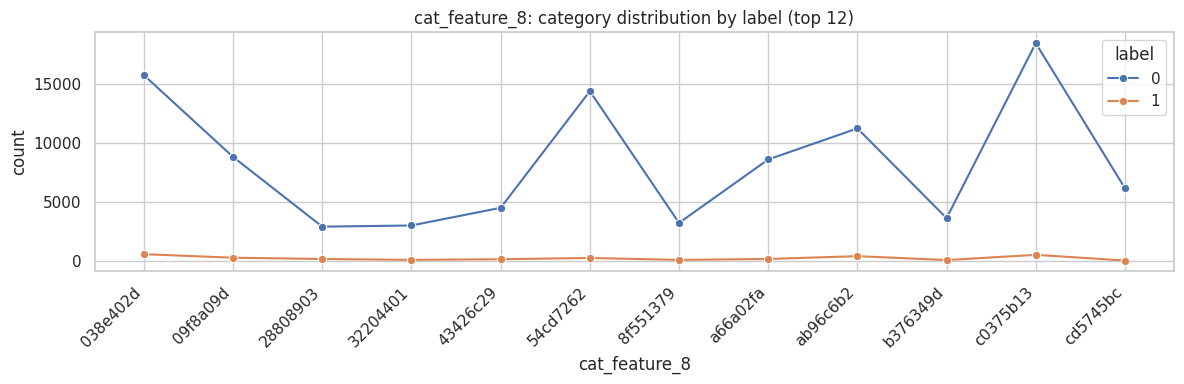

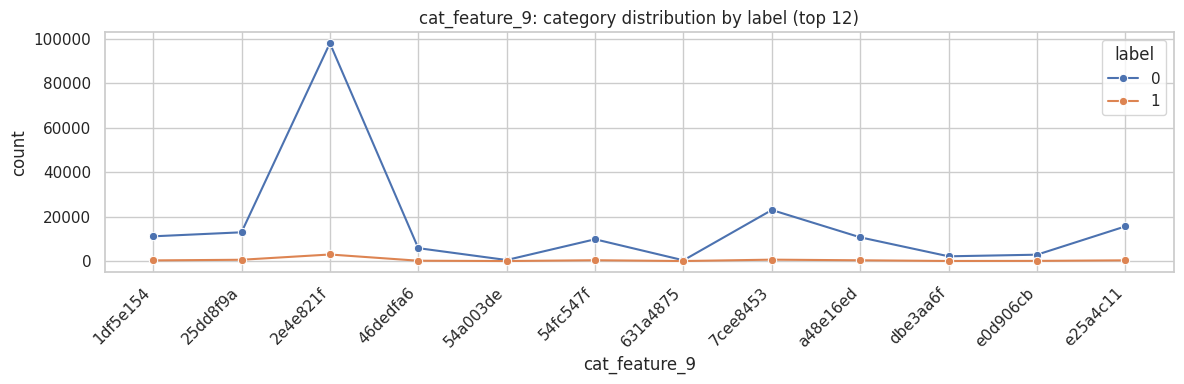

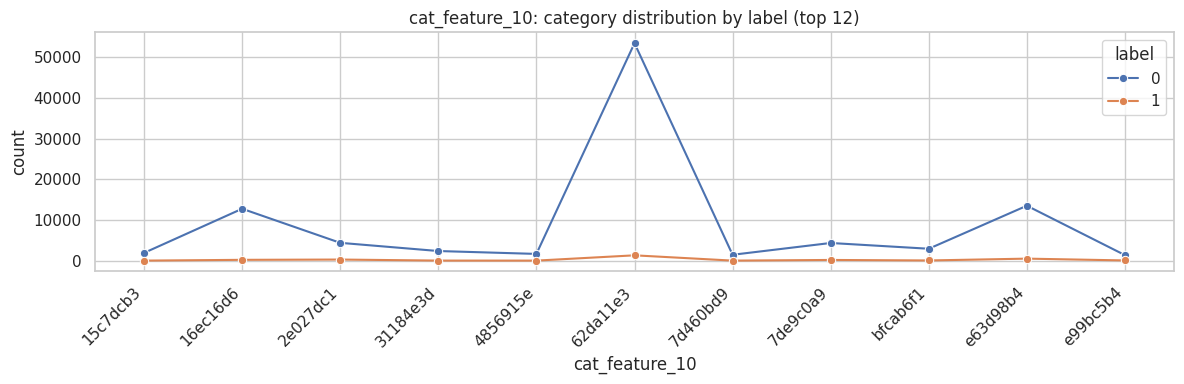

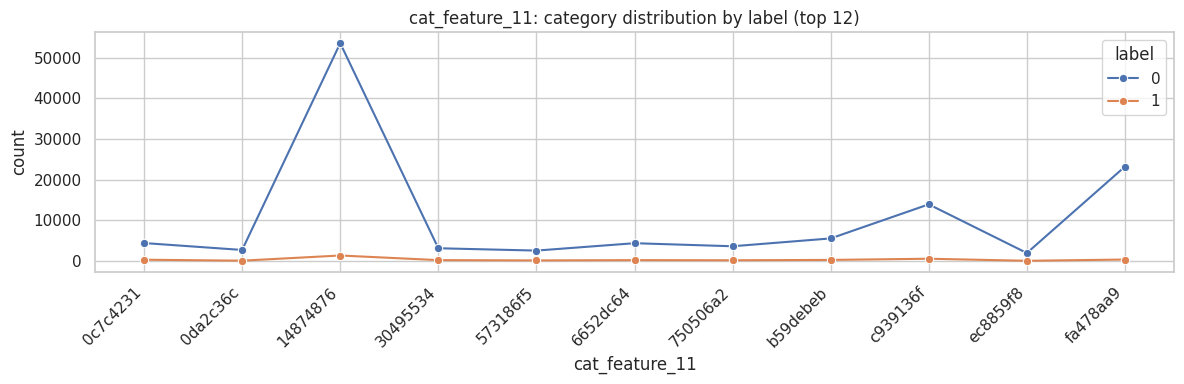

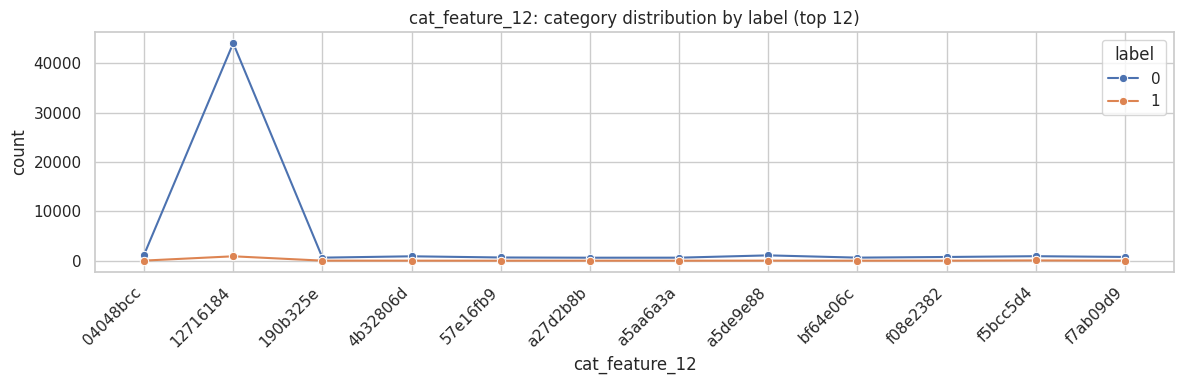

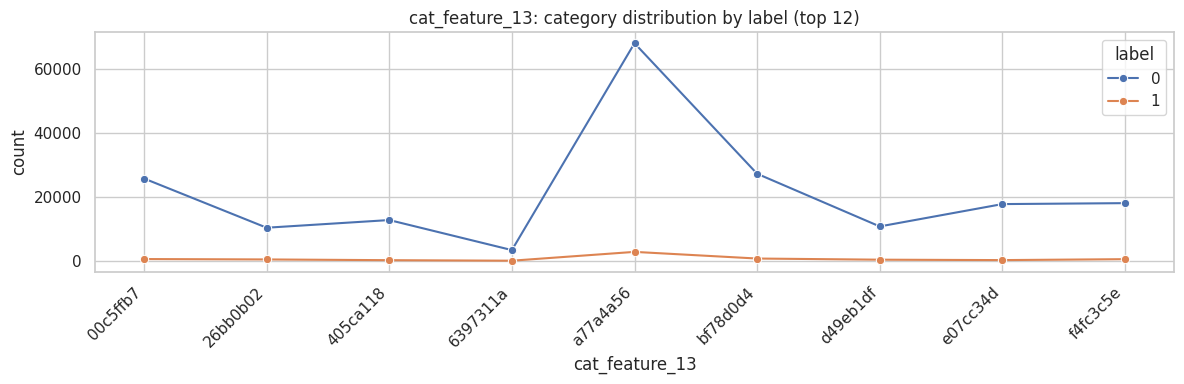

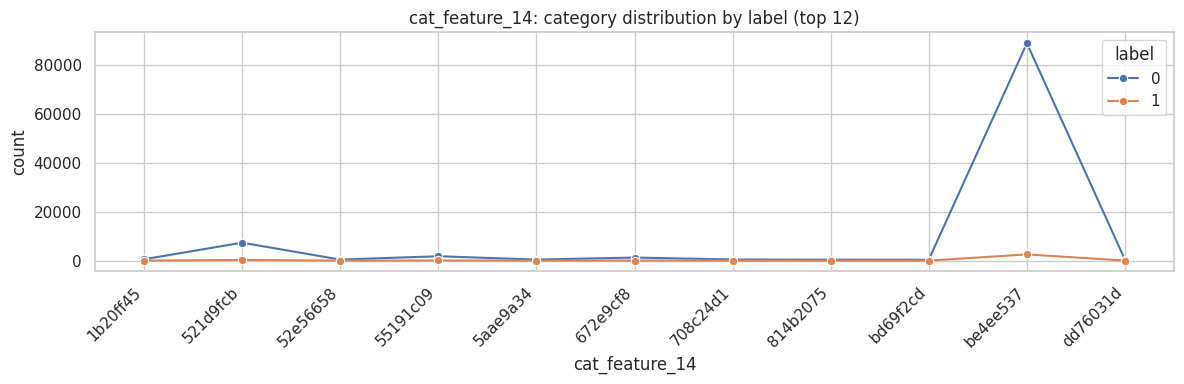

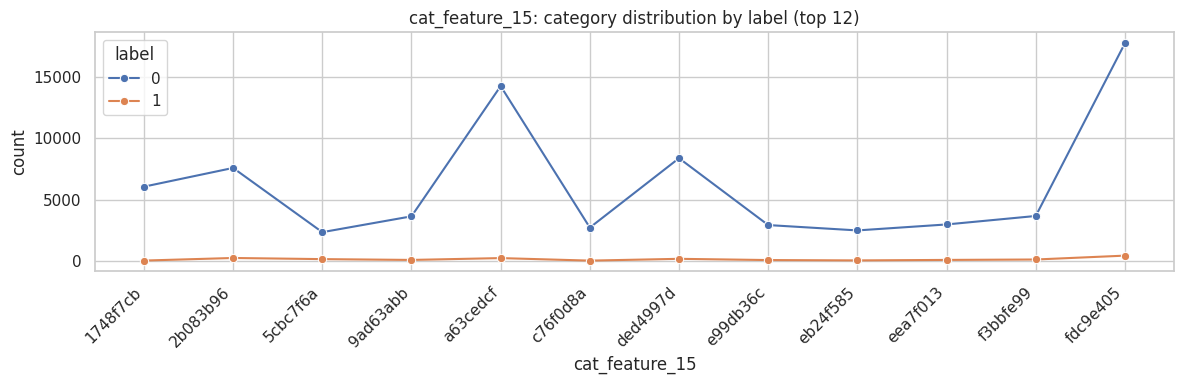

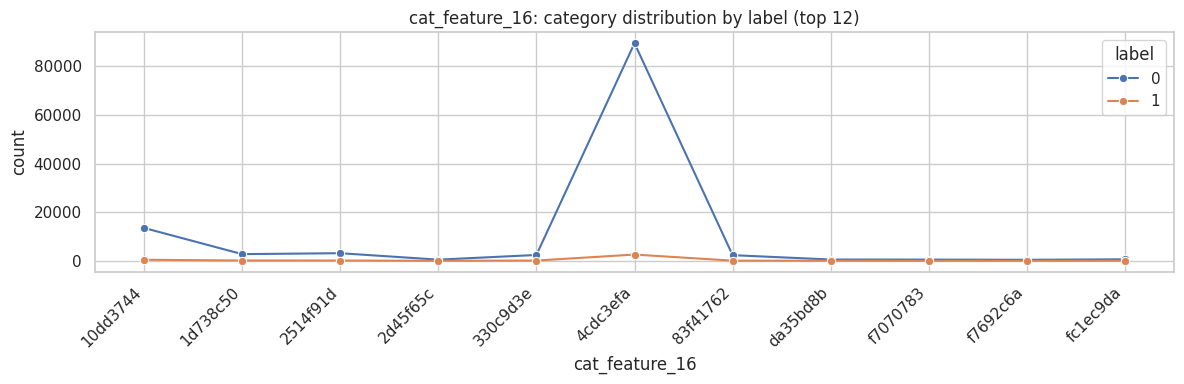

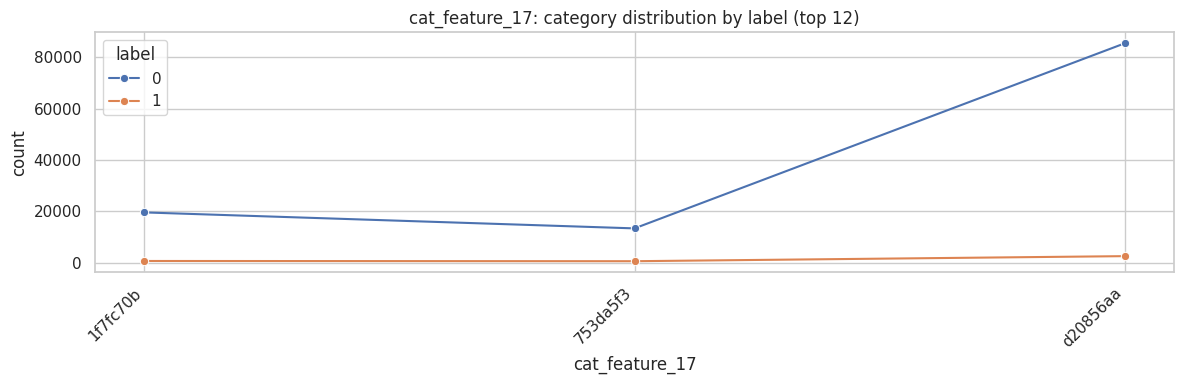

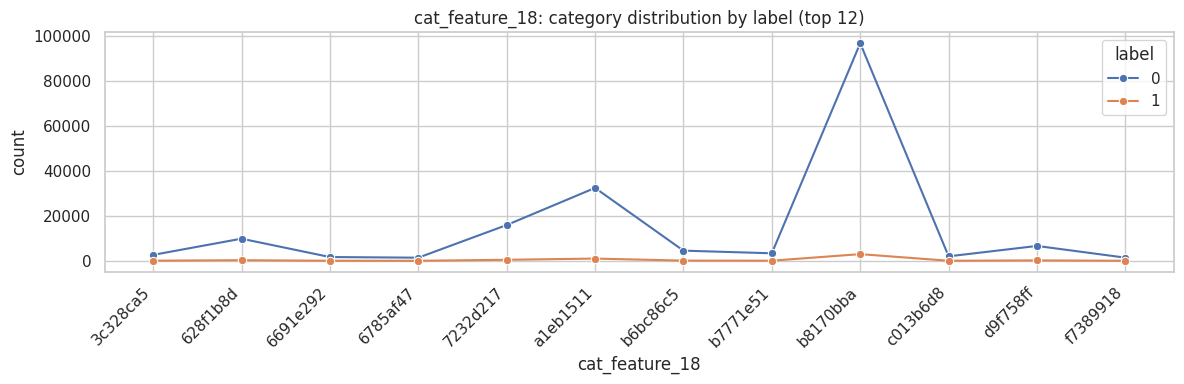

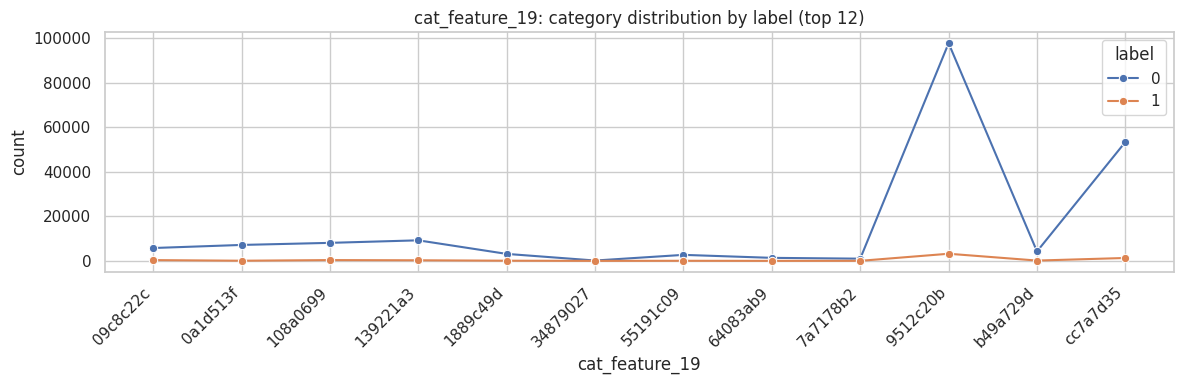

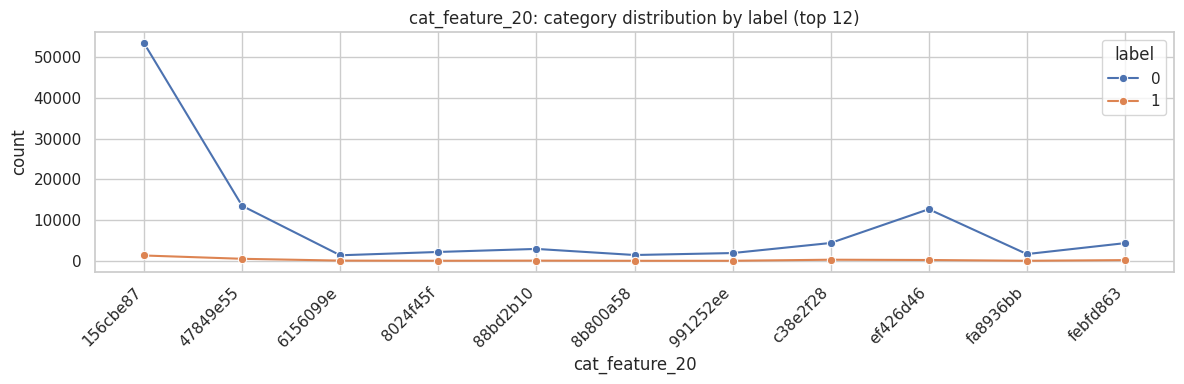

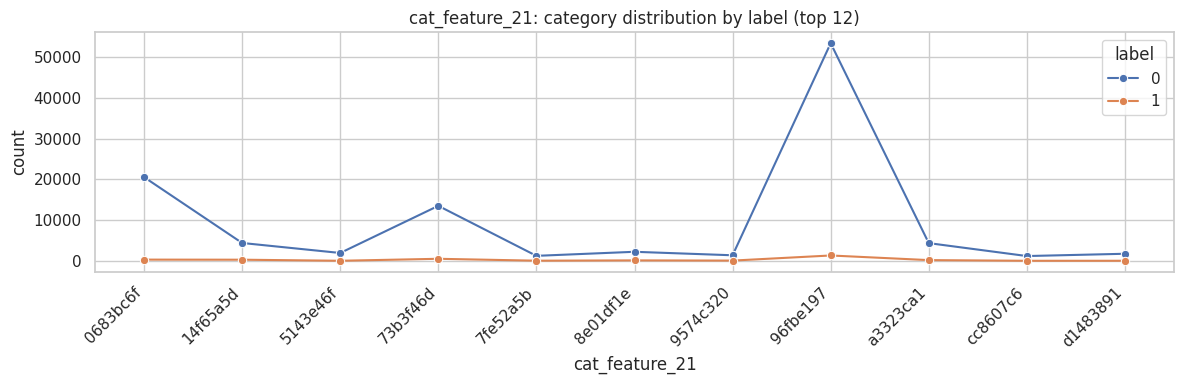

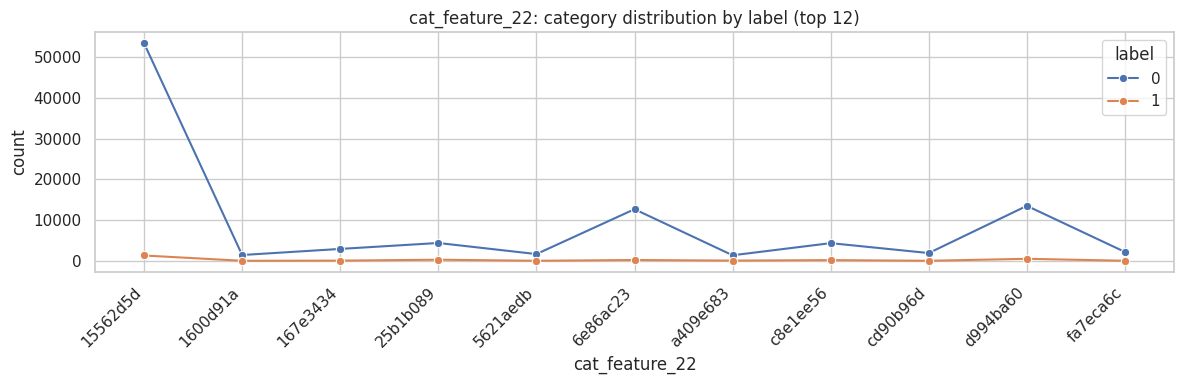

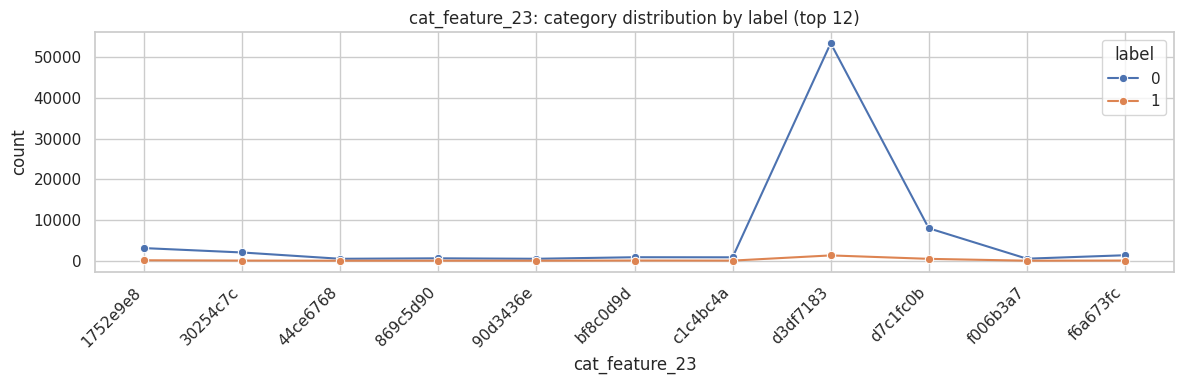

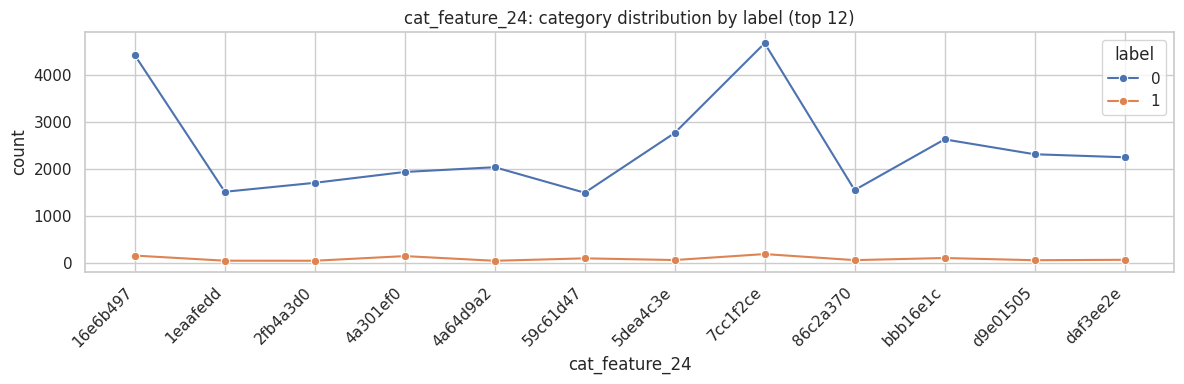

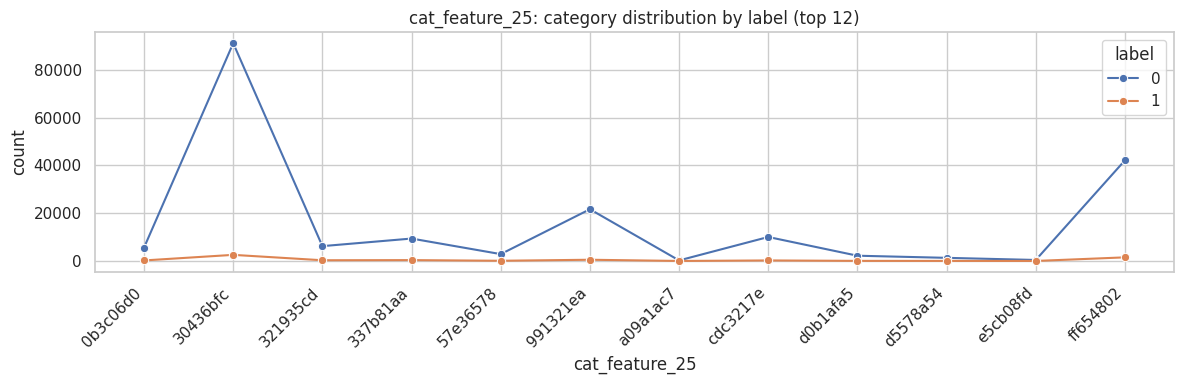

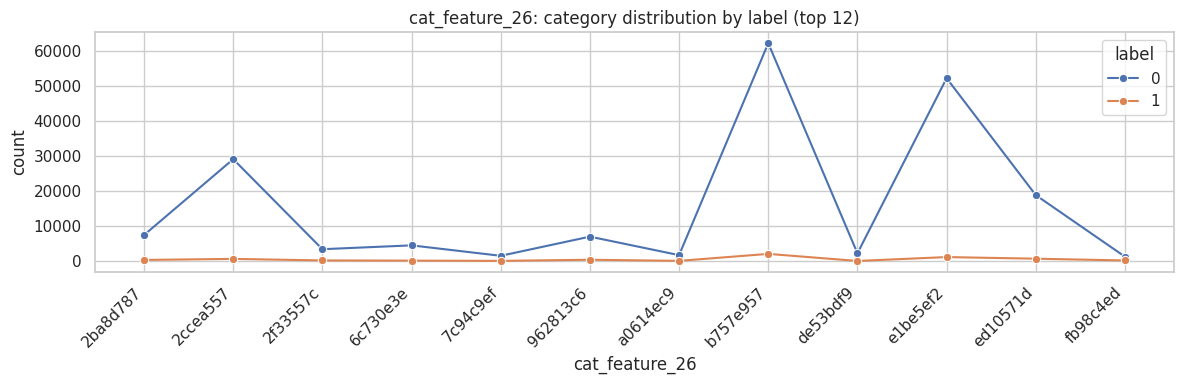

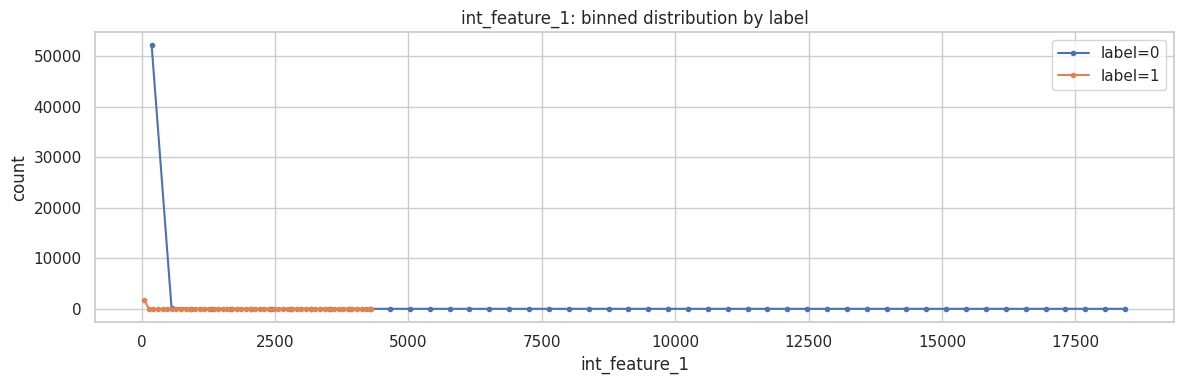

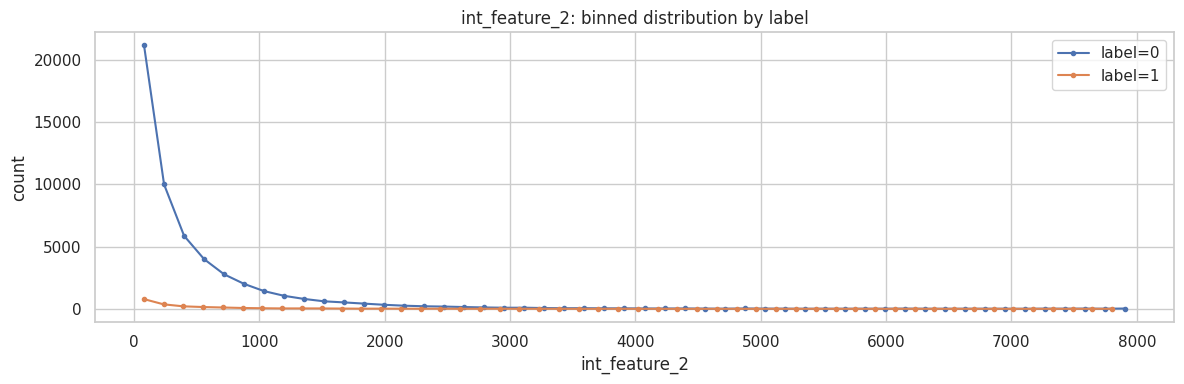

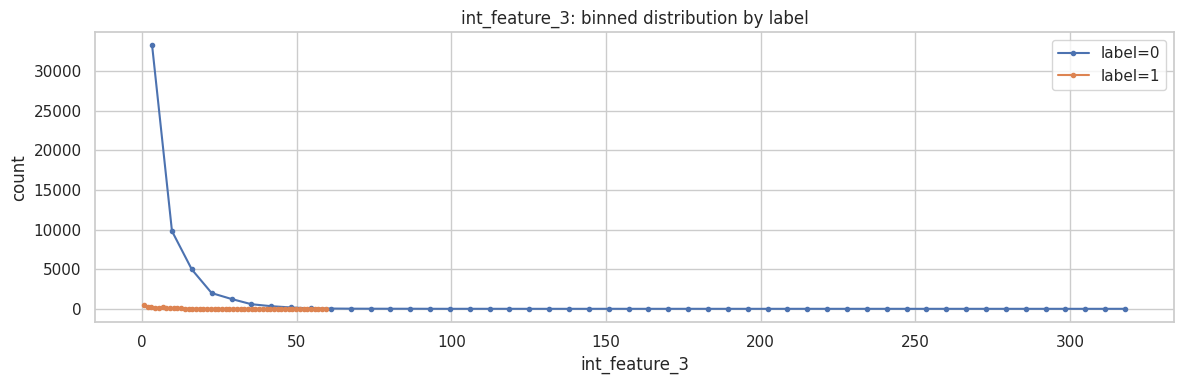

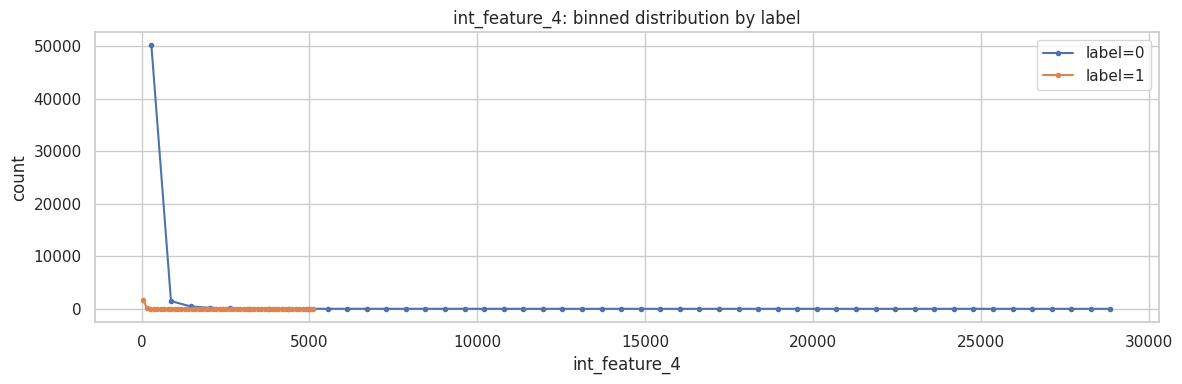

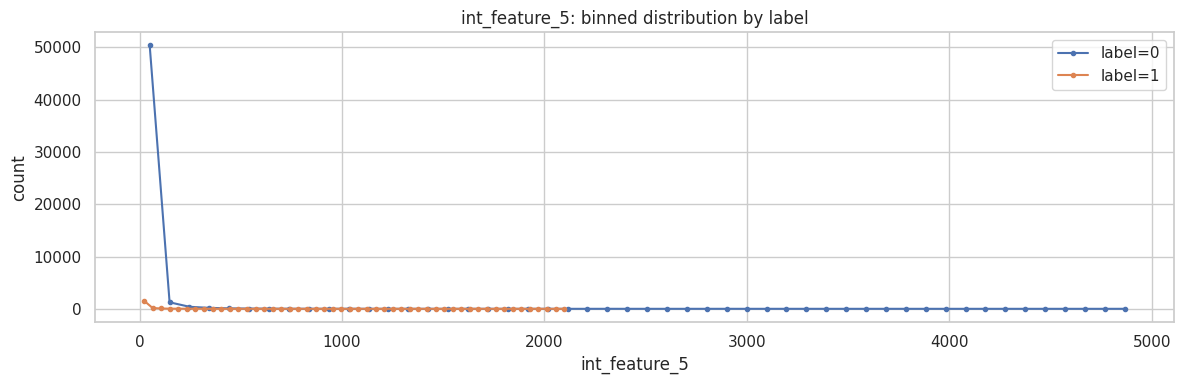

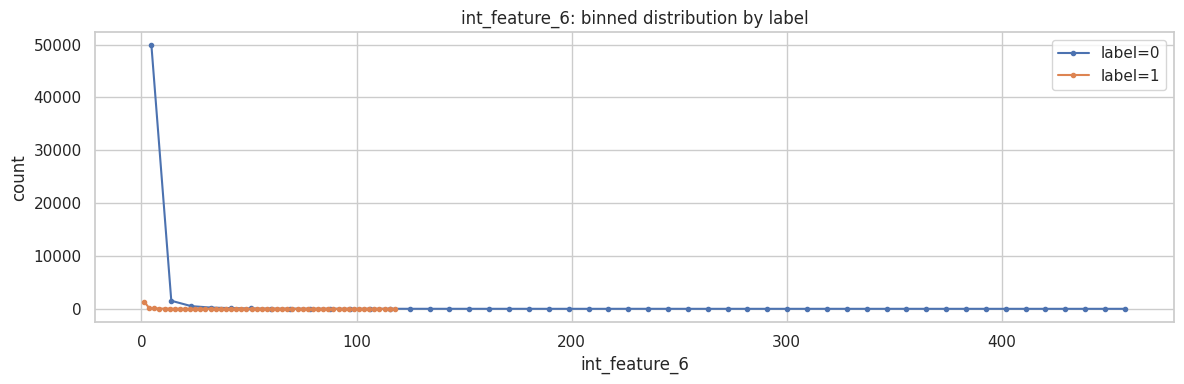

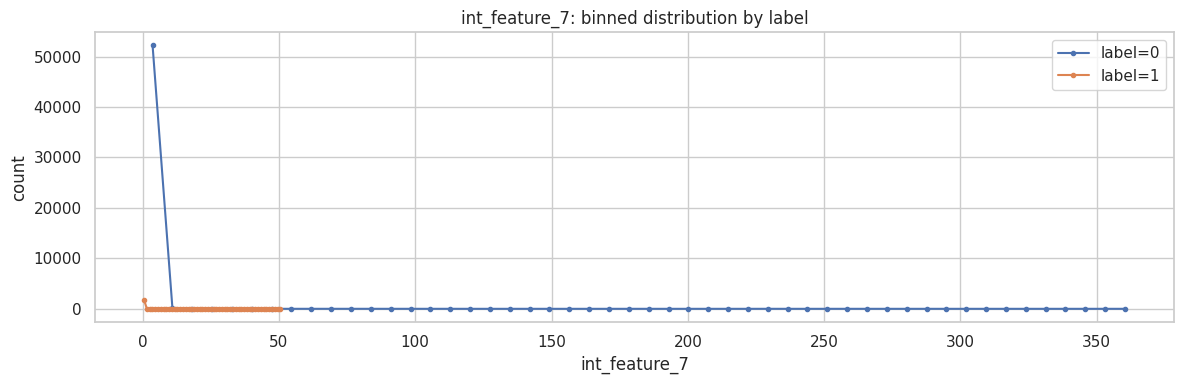

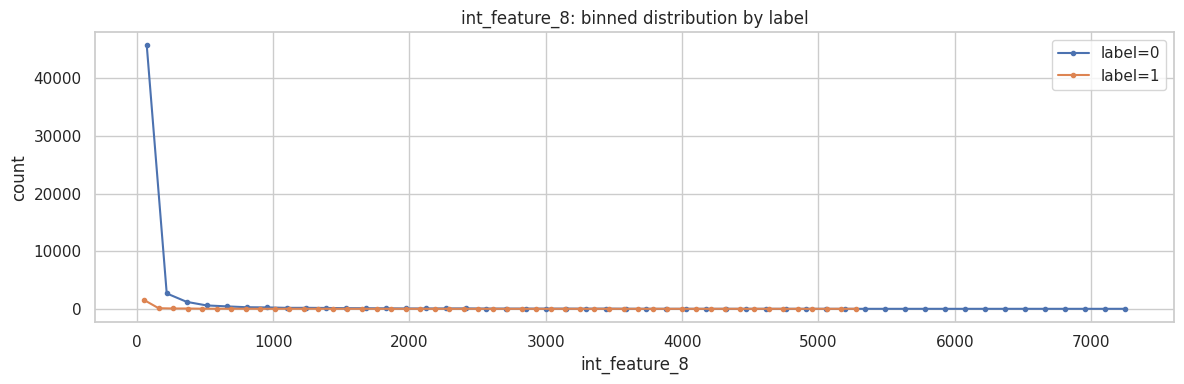

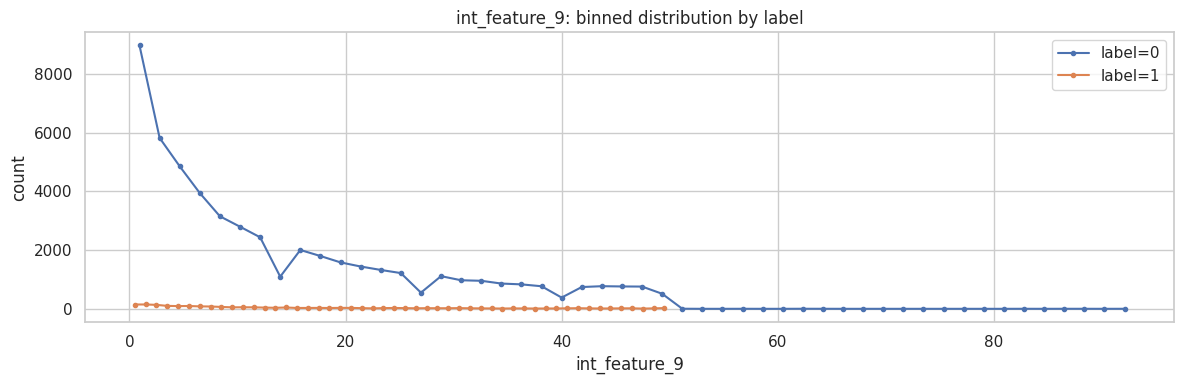

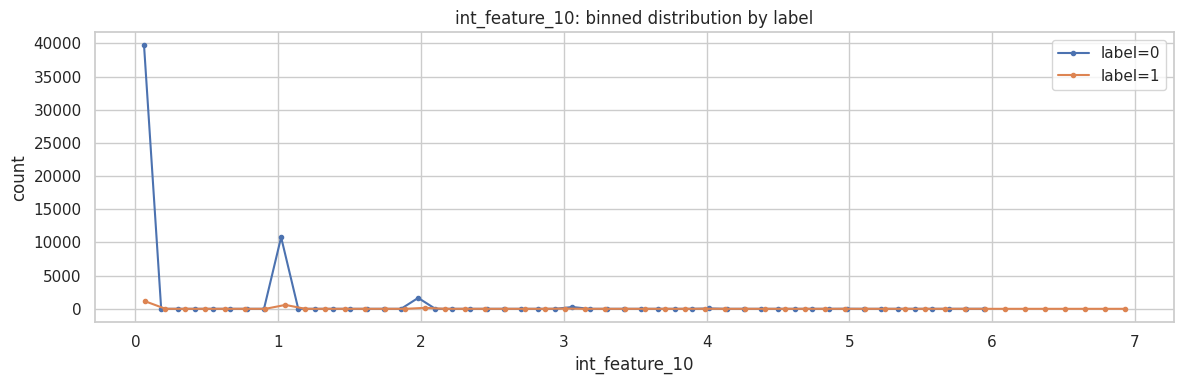

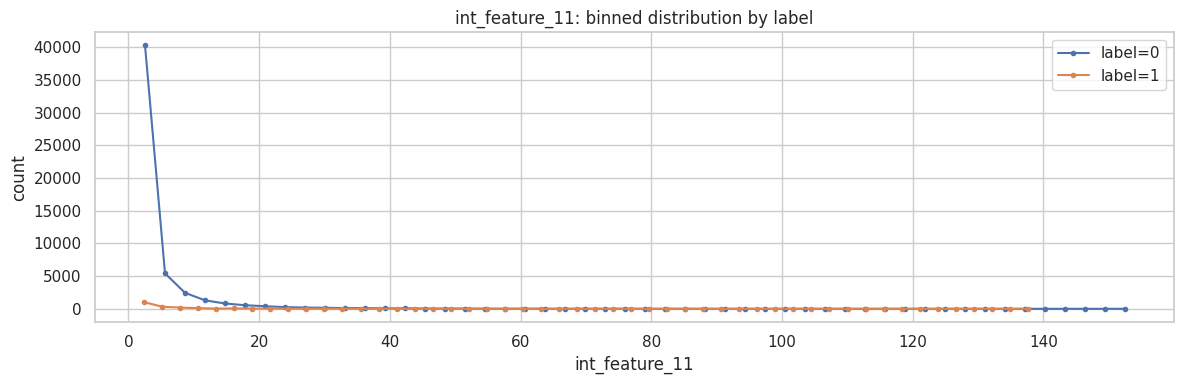

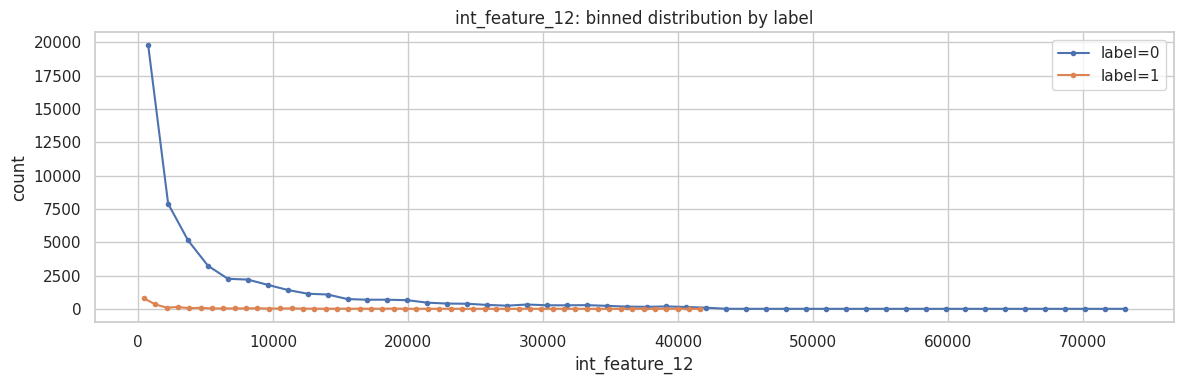

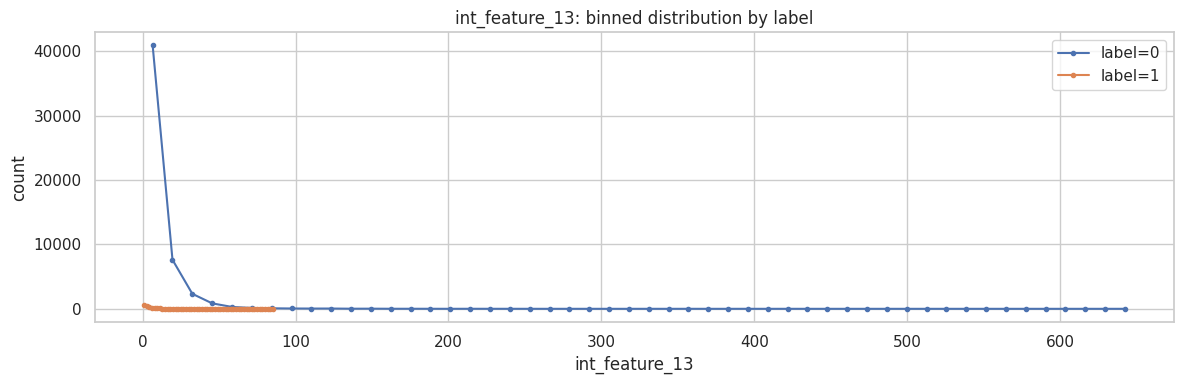

In [18]:
# Run plots
plot_category_lines(plot_df, cat_cols, top_n=12)
plot_int_lines(plot_df, int_cols, bins=50)